# Create stereoplots, fracture sets and the GeoDFN input

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import mplstereonet
import scipy.stats as stats
from scipy.stats import vonmises
from scipy import integrate, optimize

In [125]:
# Import data
fracture_data = pd.read_excel("WellCAD fracture data.xlsx")
TVD_data = pd.read_excel("WellCAD TVD.xlsx")

In [126]:
# Split into light and dark traces
trace_light = fracture_data[fracture_data['Classification'] == 'Light']
trace_dark = fracture_data[fracture_data['Classification'] == 'Dark']

# Split into categories good medium bad
light_good = trace_light[(trace_light['Light score '] >= 3) & (trace_light['Light score '] <= 6)]
light_medium = trace_light[(trace_light['Light score '] >= 7) & (trace_light['Light score '] <= 8)]
light_bad = trace_light[(trace_light['Light score '] >= 9) & (trace_light['Light score '] <= 12)]

dark_good = trace_dark[(trace_dark['Dark score '] >= 3) & (trace_dark['Dark score '] <= 4)]
dark_bad = trace_dark[(trace_dark['Dark score '] >= 5) & (trace_dark['Dark score '] <= 6)]

In [127]:
# Split per category 
light_lenght1 = fracture_data[fracture_data['Trace length - light'] == 1]
light_lenght2 = fracture_data[fracture_data['Trace length - light'] == 2]
light_lenght3 = fracture_data[fracture_data['Trace length - light'] == 3]

light_quality1 = fracture_data[fracture_data['Trace quality - light'] == 1]
light_quality2 = fracture_data[fracture_data['Trace quality - light'] == 2]
light_quality3 = fracture_data[fracture_data['Trace quality - light'] == 3]

light_isolation1 = fracture_data[fracture_data['Trace isolation'] == 1]
light_isolation2 = fracture_data[fracture_data['Trace isolation'] == 2]
light_isolation3 = fracture_data[fracture_data['Trace isolation'] == 3]

light_visibility1 = fracture_data[fracture_data['Trace visibility '] == 1]
light_visibility2 = fracture_data[fracture_data['Trace visibility '] == 2]
light_visibility3 = fracture_data[fracture_data['Trace visibility '] == 3]

dark_lenght1 = fracture_data[fracture_data['Trace length - dark'] == 1]
dark_lenght2 = fracture_data[fracture_data['Trace length - dark'] == 2]

dark_outline1 = fracture_data[fracture_data['Trace quality - dark'] == 1]
dark_outline2 = fracture_data[fracture_data['Trace quality - dark'] == 2]

dark_TT1 = fracture_data[fracture_data['Travel time response'] == 1]
dark_TT2 = fracture_data[fracture_data['Travel time response'] == 2]

### Create csv files

In [ ]:
# # Round azimuth and dip columns to integers so that stereonet 11 can read the data
# FracSet1["Azimuth [deg]"] = FracSet1["Azimuth [deg]"].round(0)
# FracSet1["Dip [deg]"] = FracSet1["Dip [deg]"].round(0)

# # Create csv files 
# FracSet1[["Azimuth [deg]", "Dip [deg]"]].to_csv("FracSet1.csv", index=False)

### Make stereoplots 

Single data set - dark traces

C:\Users\tessa\AppData\Local\Temp\ipykernel_23452\1943298853.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


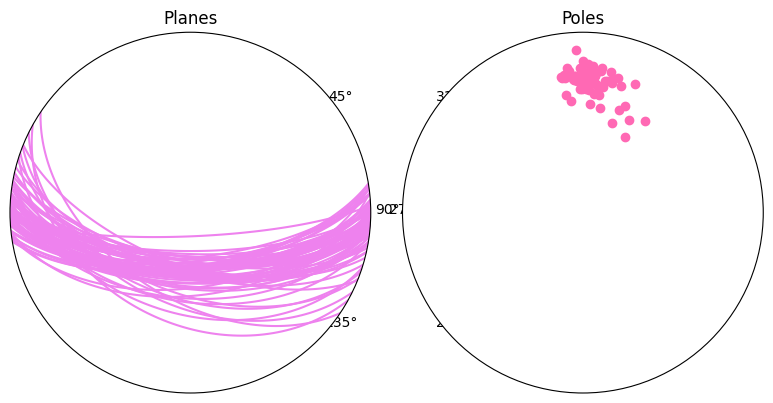

In [129]:
# Recalculate dip direction to strike 
strikes = (trace_dark['Azimuth [deg]'] - 90) % 360
dips = trace_dark['Dip [deg]']

# Format the arrays correctly 
strikes = np.asarray(strikes).copy()
dips = np.asarray(dips).copy()

# Plot the lines and poles
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(8, 4))

ax1.plane(strikes, dips, 'violet')
ax1.set_title("Planes")

ax2.pole(strikes, dips, marker='o', color='hotpink')
ax2.set_title("Poles")

plt.tight_layout()
plt.show()

Double data set - dark traces split into good and bad

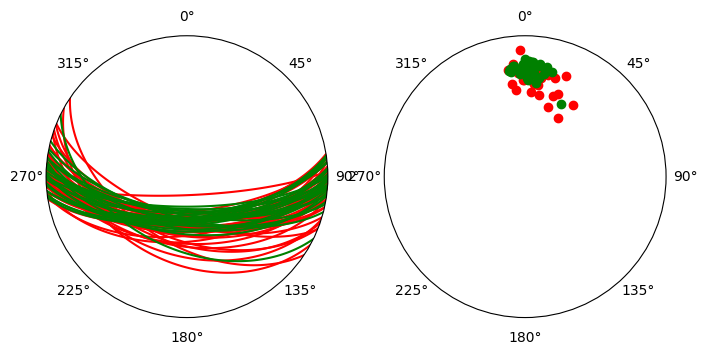

In [130]:
# Recalculate dip direction to strike 
strikes1 = (dark_good['Azimuth [deg]'] - 90) % 360
dips1 = dark_good['Dip [deg]']

strikes2 = (dark_bad['Azimuth [deg]'] - 90) % 360
dips2 = dark_bad['Dip [deg]']

# Format the arrays correctly 
strikes1 = np.asarray(strikes1).copy()
dips1 = np.asarray(dips1).copy()

strikes2 = np.asarray(strikes2).copy()
dips2 = np.asarray(dips2).copy()

# Plot the lines and poles
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(8, 4))

ax1.plane(strikes2, dips2, 'red')
ax1.plane(strikes1, dips1, 'green')

ax2.pole(strikes2, dips2, marker='o', color='red')
ax2.pole(strikes1, dips1, marker='o', color='green')

plt.show()

Triple data set - light traces good, medium and bad

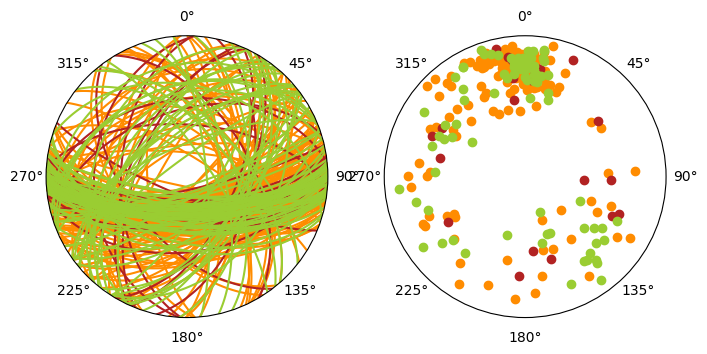

In [131]:
# Recalculate dip direction to strike 
good_strike = (light_good['Azimuth [deg]'] - 90) % 360
good_dip = light_good['Dip [deg]']

medium_strike = (light_medium['Azimuth [deg]'] - 90) % 360
medium_dip = light_medium['Dip [deg]']

bad_strike = (light_bad['Azimuth [deg]'] - 90) % 360
bad_dip = light_bad['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

medium_strike = np.asarray(medium_strike).copy()
medium_dip = np.asarray(medium_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot the lines and poles
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(8, 4))

ax1.plane(medium_strike, medium_dip, 'darkorange')
ax1.plane(bad_strike, bad_dip, 'firebrick')
ax1.plane(good_strike, good_dip, 'yellowgreen')

ax2.pole(medium_strike, medium_dip, marker='o', color='darkorange')
ax2.pole(bad_strike, bad_dip, marker='o', color='firebrick')
ax2.pole(good_strike, good_dip, marker='o', color='yellowgreen')

plt.show()

Stereoplots per classification category 

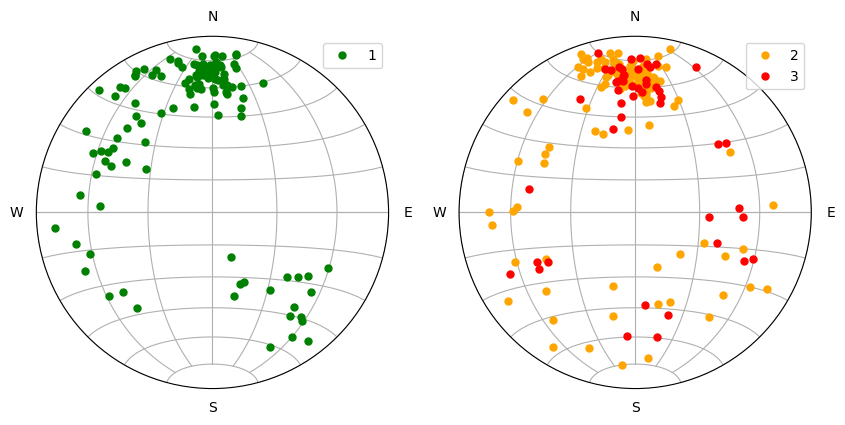

In [132]:
# Recalculate dip direction to strike 
good_strike = (light_lenght1['Azimuth [deg]'] - 90) % 360
good_dip = light_lenght1['Dip [deg]']

medium_strike = (light_lenght2['Azimuth [deg]'] - 90) % 360
medium_dip = light_lenght2['Dip [deg]']

bad_strike = (light_lenght3['Azimuth [deg]'] - 90) % 360
bad_dip = light_lenght3['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

medium_strike = np.asarray(medium_strike).copy()
medium_dip = np.asarray(medium_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot poles only
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(10, 5))

ax1.grid(True)
ax2.grid(True)

ax1.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])
ax2.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax1.pole(good_strike, good_dip, marker='o', color='green', markersize=5, label='1')
ax1.legend(loc='upper right')

ax2.pole(medium_strike, medium_dip, marker='o', color='orange', markersize=5, label='2')
ax2.pole(bad_strike, bad_dip, marker='o', color='red', markersize=5, label='3')
ax2.legend(loc='upper right')

plt.show()

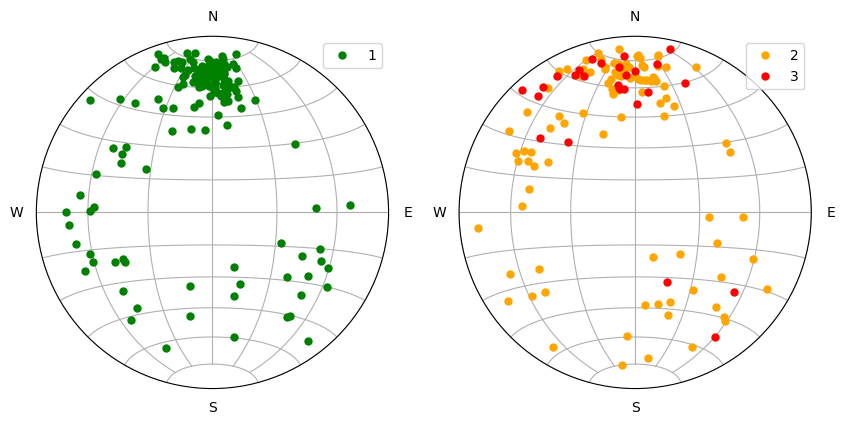

In [133]:
# Recalculate dip direction to strike 
good_strike = (light_quality1['Azimuth [deg]'] - 90) % 360
good_dip = light_quality1['Dip [deg]']

medium_strike = (light_quality2['Azimuth [deg]'] - 90) % 360
medium_dip = light_quality2['Dip [deg]']

bad_strike = (light_quality3['Azimuth [deg]'] - 90) % 360
bad_dip = light_quality3['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

medium_strike = np.asarray(medium_strike).copy()
medium_dip = np.asarray(medium_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot poles only
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(10, 5))

ax1.grid(True)
ax2.grid(True)

ax1.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])
ax2.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax1.pole(good_strike, good_dip, marker='o', color='green', markersize=5, label='1')
ax1.legend(loc='upper right')

ax2.pole(medium_strike, medium_dip, marker='o', color='orange', markersize=5, label='2')
ax2.pole(bad_strike, bad_dip, marker='o', color='red', markersize=5, label='3')
ax2.legend(loc='upper right')

plt.show()

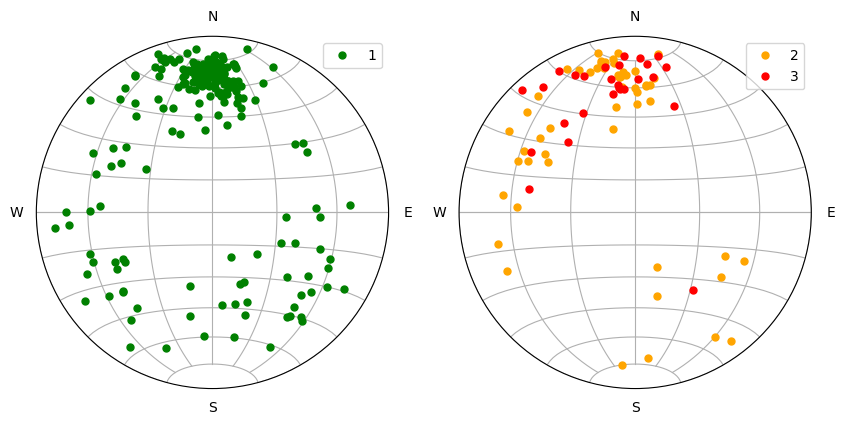

In [134]:
# Recalculate dip direction to strike 
good_strike = (light_isolation1['Azimuth [deg]'] - 90) % 360
good_dip = light_isolation1['Dip [deg]']

medium_strike = (light_isolation2['Azimuth [deg]'] - 90) % 360
medium_dip = light_isolation2['Dip [deg]']

bad_strike = (light_isolation3['Azimuth [deg]'] - 90) % 360
bad_dip = light_isolation3['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

medium_strike = np.asarray(medium_strike).copy()
medium_dip = np.asarray(medium_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot poles only
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(10, 5))

ax1.grid(True)
ax2.grid(True)

ax1.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])
ax2.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax1.pole(good_strike, good_dip, marker='o', color='green', markersize=5, label='1')
ax1.legend(loc='upper right')

ax2.pole(medium_strike, medium_dip, marker='o', color='orange', markersize=5, label='2')
ax2.pole(bad_strike, bad_dip, marker='o', color='red', markersize=5, label='3')
ax2.legend(loc='upper right')

plt.show()

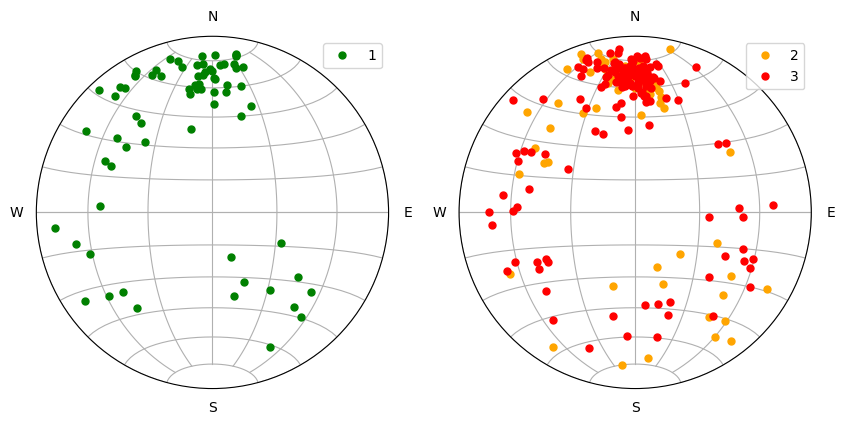

In [135]:
# Recalculate dip direction to strike 
good_strike = (light_visibility1['Azimuth [deg]'] - 90) % 360
good_dip = light_visibility1['Dip [deg]']

medium_strike = (light_visibility2['Azimuth [deg]'] - 90) % 360
medium_dip = light_visibility2['Dip [deg]']

bad_strike = (light_visibility3['Azimuth [deg]'] - 90) % 360
bad_dip = light_visibility3['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

medium_strike = np.asarray(medium_strike).copy()
medium_dip = np.asarray(medium_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot poles only
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(10, 5))

ax1.grid(True)
ax2.grid(True)

ax1.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])
ax2.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax1.pole(good_strike, good_dip, marker='o', color='green', markersize=5, label='1')
ax1.legend(loc='upper right')

ax2.pole(medium_strike, medium_dip, marker='o', color='orange', markersize=5, label='2')
ax2.pole(bad_strike, bad_dip, marker='o', color='red', markersize=5, label='3')
ax2.legend(loc='upper right')

plt.show()

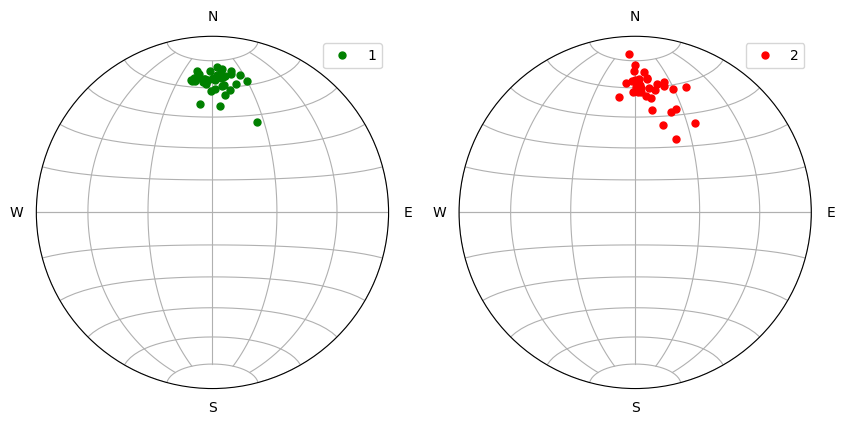

In [136]:
# Recalculate dip direction to strike 
good_strike = (dark_lenght1['Azimuth [deg]'] - 90) % 360
good_dip = dark_lenght1['Dip [deg]']

bad_strike = (dark_lenght2['Azimuth [deg]'] - 90) % 360
bad_dip = dark_lenght2['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot poles only
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(10, 5))

ax1.grid(True)
ax2.grid(True)

ax1.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])
ax2.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax1.pole(good_strike, good_dip, marker='o', color='green', markersize=5, label='1')
ax1.legend(loc='upper right')

ax2.pole(bad_strike, bad_dip, marker='o', color='red', markersize=5, label='2')
ax2.legend(loc='upper right')

plt.show()

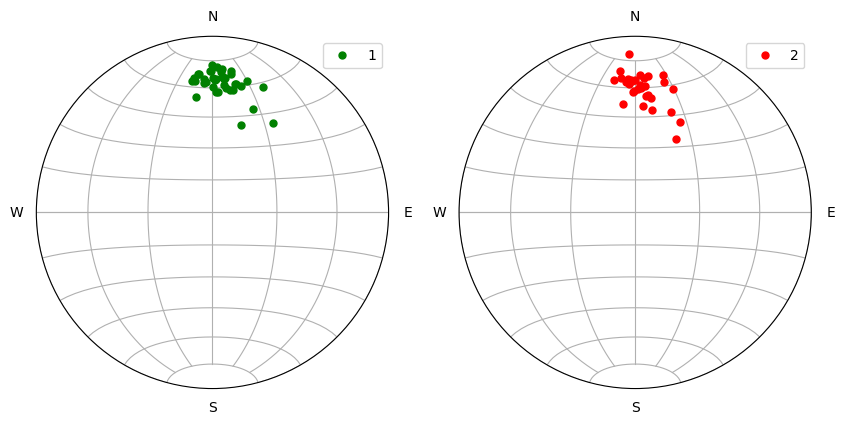

In [137]:
# Recalculate dip direction to strike 
good_strike = (dark_outline1['Azimuth [deg]'] - 90) % 360
good_dip = dark_outline1['Dip [deg]']

bad_strike = (dark_outline2['Azimuth [deg]'] - 90) % 360
bad_dip = dark_outline2['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot poles only
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(10, 5))

ax1.grid(True)
ax2.grid(True)

ax1.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])
ax2.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax1.pole(good_strike, good_dip, marker='o', color='green', markersize=5, label='1')
ax1.legend(loc='upper right')

ax2.pole(bad_strike, bad_dip, marker='o', color='red', markersize=5, label='2')
ax2.legend(loc='upper right')

plt.show()

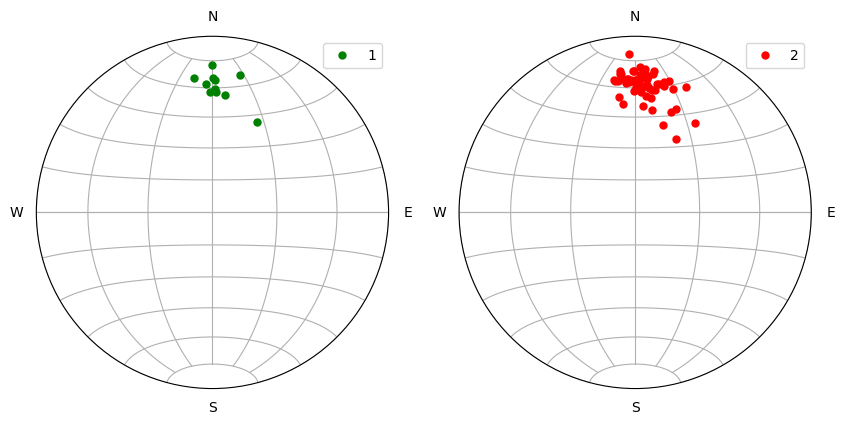

In [138]:
# Recalculate dip direction to strike 
good_strike = (dark_TT1['Azimuth [deg]'] - 90) % 360
good_dip = dark_TT1['Dip [deg]']

bad_strike = (dark_TT2['Azimuth [deg]'] - 90) % 360
bad_dip = dark_TT2['Dip [deg]']

# Format the arrays correctly 
good_strike = np.asarray(good_strike).copy()
good_dip = np.asarray(good_dip).copy()

bad_strike = np.asarray(bad_strike).copy()
bad_dip = np.asarray(bad_dip).copy()

# Plot poles only
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(10, 5))

ax1.grid(True)
ax2.grid(True)

ax1.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])
ax2.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax1.pole(good_strike, good_dip, marker='o', color='green', markersize=5, label='1')
ax1.legend(loc='upper right')

ax2.pole(bad_strike, bad_dip, marker='o', color='red', markersize=5, label='2')
ax2.legend(loc='upper right')

plt.show()

Poles only

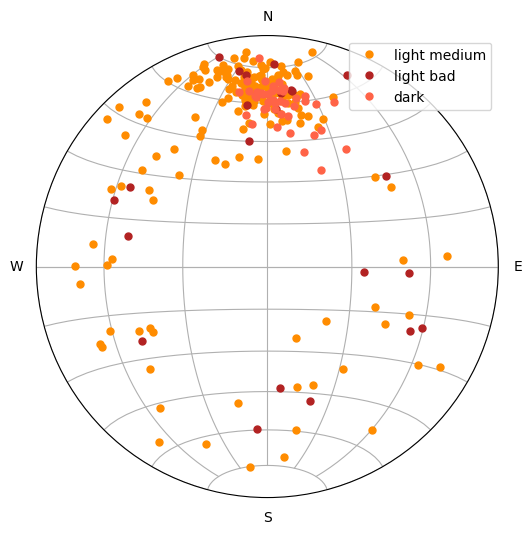

In [139]:
# Recalculate dip direction to strike 
strikes1 = (light_medium['Azimuth [deg]'] - 90) % 360
dips1 = light_medium['Dip [deg]']

strikes2 = (light_bad['Azimuth [deg]'] - 90) % 360
dips2 = light_bad['Dip [deg]']

strikes3 = (dark_bad['Azimuth [deg]'] - 90) % 360
dips3 = dark_bad['Dip [deg]']

# Format the arrays correctly 
strikes1 = np.asarray(strikes1).copy()
dips1 = np.asarray(dips1).copy()

strikes2 = np.asarray(strikes2).copy()
dips2 = np.asarray(dips2).copy()

strikes3 = np.asarray(strikes3).copy()
dips3 = np.asarray(dips3).copy()

# Plot poles only
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='stereonet')

ax.grid(True)

ax.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax.pole(strikes1, dips1, marker='o', color='darkorange', markersize=5, label='light medium')
ax.pole(strikes2, dips2, marker='o', color='firebrick', markersize=5, label='light bad')
ax.pole(strikes3, dips3, marker='o', color='tomato', markersize=5, label='dark')
ax.legend(loc='upper right')

plt.show()

Planes only

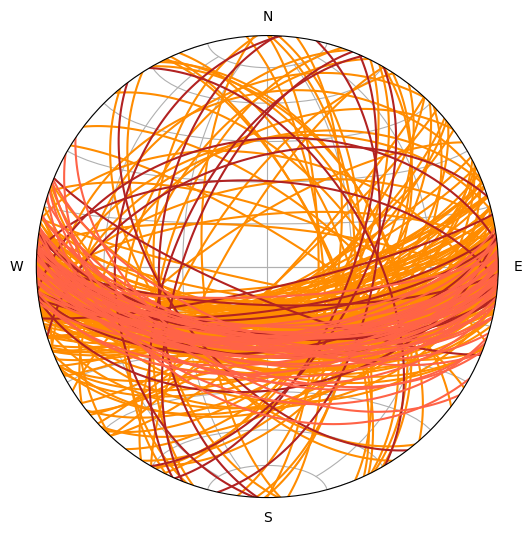

In [140]:
# Recalculate dip direction to strike 
strikes1 = (light_medium['Azimuth [deg]'] - 90) % 360
dips1 = light_medium['Dip [deg]']

strikes2 = (light_bad['Azimuth [deg]'] - 90) % 360
dips2 = light_bad['Dip [deg]']

strikes3 = (dark_bad['Azimuth [deg]'] - 90) % 360
dips3 = dark_bad['Dip [deg]']

# Format the arrays correctly 
strikes1 = np.asarray(strikes1).copy()
dips1 = np.asarray(dips1).copy()

strikes2 = np.asarray(strikes2).copy()
dips2 = np.asarray(dips2).copy()

strikes3 = np.asarray(strikes3).copy()
dips3 = np.asarray(dips3).copy()

# Plot poles only
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='stereonet')

ax.grid(True)

ax.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax.plane(strikes1, dips1, color='darkorange', label='darkorange')
ax.plane(strikes2, dips2, color='firebrick', label='firebrick')
ax.plane(strikes3, dips3, color='tomato', label='tomato')

plt.show()

# Add TVD depth to fracture dataframe

In [141]:
depth_to_tvd = TVD_data.set_index('Depth [m]')['TVD axis [m]']

fracture_data['TVD'] = fracture_data['Depth [m]'].map(depth_to_tvd)

# Extract fracture sets

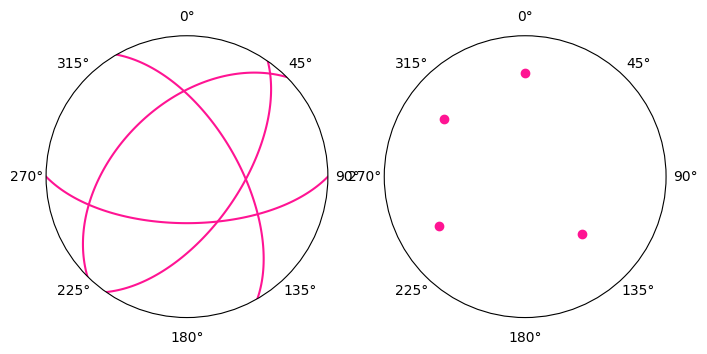

In [142]:
# Define mid points for each set 
midpoint_strike = np.array ([180, 125, 60, 315])
midpoint_dip = np.array ([63, 60, 60, 48])

midpoint_strike = (midpoint_strike - 90) % 360
midpoint_dip = midpoint_dip

# Format the arrays correctly 
strikes = np.asarray(strikes1).copy()
dips = np.asarray(dips1).copy()

# Plot the lines and poles
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'stereonet'}, figsize=(8, 4))

#ax1.plane(strikes, dips, 'green')
ax1.plane(midpoint_strike, midpoint_dip, 'deeppink')

#ax2.pole(strikes, dips, marker='o', color='green')
ax2.pole(midpoint_strike, midpoint_dip, marker='o', color='deeppink')

plt.show()

In [143]:
# Define functions to calculate fracture sets 

# Function to convert dip angle and direction to vectors representing the poles 
def pole_to_vector(dipdir, dip):
    """
    Convert plane orientation (dip direction, dip)
    to a unit vector representing the pole.
    """

    trend = np.radians((dipdir + 180) % 360)
    plunge = np.radians(90 - dip)

    x = np.cos(plunge) * np.sin(trend)
    y = np.cos(plunge) * np.cos(trend)
    z = np.sin(plunge)

    return np.column_stack((x, y, z))

# Calculate angular distances 
def angular_distance(vectors, centre):

    dot = vectors @ centre

    dot = np.clip(dot, -1, 1)

    return np.degrees(np.arccos(dot))

In [144]:
# Find fracture sets 

# Create vectors for all fractures 
vectors = pole_to_vector(fracture_data["Azimuth [deg]"], fracture_data["Dip [deg]"])

# Define midpoints and radii
fracture_sets = [
    {"dipdir": 180,  "dip": 63, "radius": 20},
    {"dipdir": 125, "dip": 60, "radius": 20},
    {"dipdir": 60, "dip": 60, "radius": 20},
    {"dipdir": 315, "dip": 48, "radius": 20},
]

# Assign each fracture to either a set or define as an outlier (for overlapping circles the closest one is chosen)
best_angle = np.full(len(vectors), np.inf)
labels = np.full(len(vectors), -1)

for i, fs in enumerate(fracture_sets):

    centre = pole_to_vector(
        np.array([fs["dipdir"]]),
        np.array([fs["dip"]])
    )[0]

    angle = angular_distance(vectors, centre)

    mask = (angle < best_angle) & (angle <= fs["radius"])

    labels[mask] = i
    best_angle[mask] = angle[mask]

fracture_data["Fracture Set"] = labels

In [145]:
# Separate the fracture sets 
FracSet1 = fracture_data[fracture_data['Fracture Set'] == 0]
FracSet2 = fracture_data[fracture_data['Fracture Set'] == 1]
FracSet3 = fracture_data[fracture_data['Fracture Set'] == 2]
FracSet4 = fracture_data[fracture_data['Fracture Set'] == 3]
Outliers = fracture_data[fracture_data['Fracture Set'] == -1]

FracSet1Light = FracSet1[FracSet1['Classification'] == 'Light']

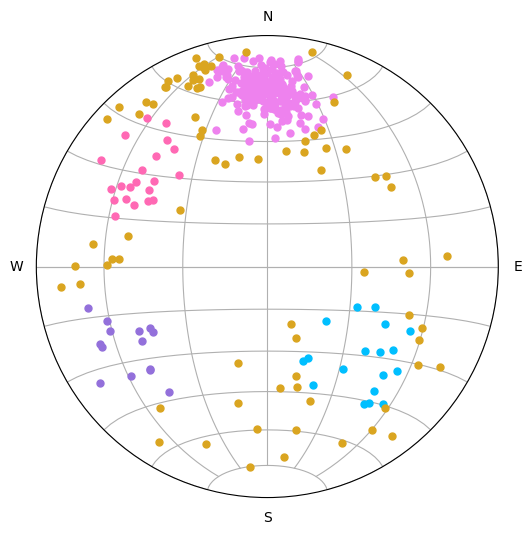

In [146]:
# Plot the results 
strikes1 = (FracSet1['Azimuth [deg]'] - 90) % 360
dips1 = FracSet1['Dip [deg]']

strikes2 = (FracSet2['Azimuth [deg]'] - 90) % 360
dips2 = FracSet2['Dip [deg]']

strikes3 = (FracSet3['Azimuth [deg]'] - 90) % 360
dips3 = FracSet3['Dip [deg]']

strikes4 = (FracSet4['Azimuth [deg]'] - 90) % 360
dips4 = FracSet4['Dip [deg]']

strikes5 = (Outliers['Azimuth [deg]'] - 90) % 360
dips5 = Outliers['Dip [deg]']

# Format the arrays correctly 
strikes1 = np.asarray(strikes1).copy()
dips1 = np.asarray(dips1).copy()

strikes2 = np.asarray(strikes2).copy()
dips2 = np.asarray(dips2).copy()

strikes3 = np.asarray(strikes3).copy()
dips3 = np.asarray(dips3).copy()

strikes4 = np.asarray(strikes4).copy()
dips4 = np.asarray(dips4).copy()

strikes5 = np.asarray(strikes5).copy()
dips5 = np.asarray(dips5).copy()

# Plot poles only
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='stereonet')

ax.grid(True)

ax.set_azimuth_ticks([0, 90, 180, 270], labels=['N', 'E', 'S', 'W'])

ax.pole(strikes1, dips1, marker='o', color='violet', markersize=5, label='FracSet1')
ax.pole(strikes2, dips2, marker='o', color='hotpink', markersize=5, label='FracSet2')
ax.pole(strikes3, dips3, marker='o', color='mediumpurple', markersize=5, label='FracSet3')
ax.pole(strikes4, dips4, marker='o', color='deepskyblue', markersize=5, label='FracSet4')
ax.pole(strikes5, dips5, marker='o', color='goldenrod', markersize=5, label='Outliers')
#ax.legend(loc='upper right')

plt.show()

Fracture sets through depth

Text(0.5, 1.0, 'Fracture set distribution through depth (MD)')

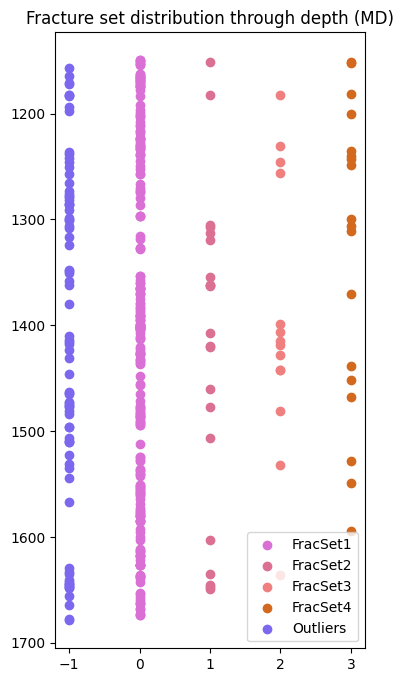

In [147]:
# See if there is a depth relation
plt.figure(figsize=(4, 8))
plt.scatter(FracSet1['Fracture Set'], FracSet1['Depth [m]'], color='orchid', label='FracSet1')
plt.scatter(FracSet2['Fracture Set'], FracSet2['Depth [m]'], color='palevioletred', label='FracSet2')
plt.scatter(FracSet3['Fracture Set'], FracSet3['Depth [m]'], color='lightcoral', label='FracSet3')
plt.scatter(FracSet4['Fracture Set'], FracSet4['Depth [m]'], color='chocolate', label='FracSet4')
plt.scatter(Outliers['Fracture Set'], Outliers['Depth [m]'], color='mediumslateblue', label='Outliers')
plt.gca().invert_yaxis()
plt.legend(loc='best')
plt.title('Fracture set distribution through depth (MD)')

# Fracture parameters for DFN generation

### Orientation

set=1, Kappa= 61.420144933987196 loc= 1.5686047498200066


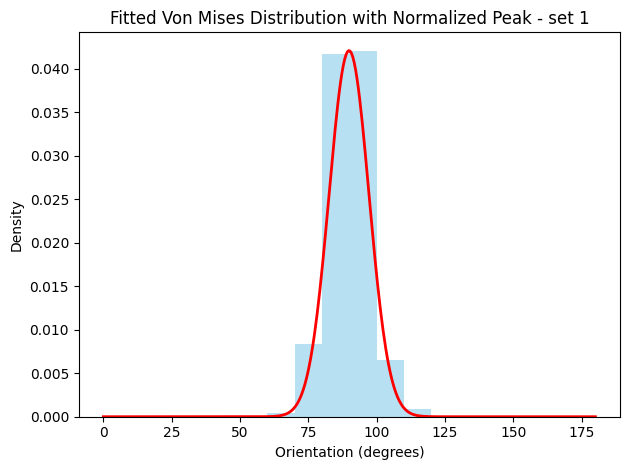

In [148]:
# Fracture set 1
current_set = FracSet1.copy()  # Use copy to avoid SettingWithCopyWarning
current_set['strike'] = (current_set['Azimuth [deg]'] - 90) % 360
current_set['correctedOrientation'] = current_set['strike'] % 180
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=1, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(0, 180, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, range=(0, 180), color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak - set 1')

# Show the plot
plt.tight_layout()
plt.show()

set=1, Kappa= 56.58513772811958 loc= 1.5544732910115302


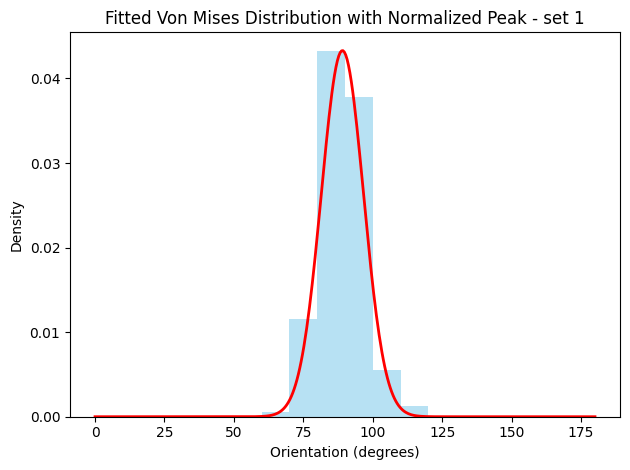

In [149]:
# Fracture set 1 LIGHT
current_set = FracSet1Light.copy()  # Use copy to avoid SettingWithCopyWarning
current_set['strike'] = (current_set['Azimuth [deg]'] - 90) % 360
current_set['correctedOrientation'] = current_set['strike'] % 180
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=1, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(0, 180, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, range=(0, 180), color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak - set 1')

# Show the plot
plt.tight_layout()
plt.show()

set=2, Kappa= 30.562598208939967 loc= 0.6247536073665279


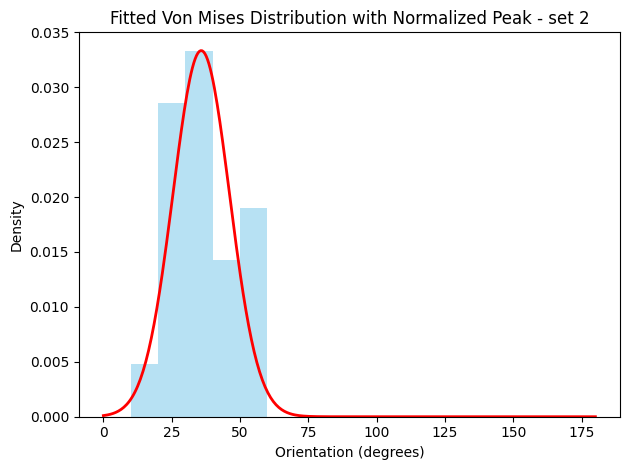

In [150]:
# Fracture set 2
current_set = FracSet2.copy()  # Use copy to avoid SettingWithCopyWarning
current_set['strike'] = (current_set['Azimuth [deg]'] - 90) % 360
current_set['correctedOrientation'] = current_set['strike'] % 180
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=2, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(0, 180, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, range=(0, 180), color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak - set 2')

# Show the plot
plt.tight_layout()
plt.show()

set=3, Kappa= 34.367616349126564 loc= 2.608679027162557


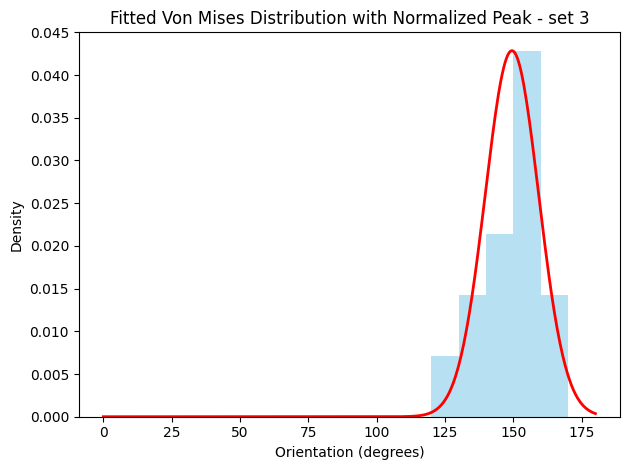

In [151]:
# Fracture set 3
current_set = FracSet3.copy()  # Use copy to avoid SettingWithCopyWarning
current_set['strike'] = (current_set['Azimuth [deg]'] - 90) % 360
current_set['correctedOrientation'] = current_set['strike'] % 180
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=3, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(0, 180, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, range=(0, 180), color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak - set 3')

# Show the plot
plt.tight_layout()
plt.show()

set=4, Kappa= 15.456337133578057 loc= 0.7717052163152696


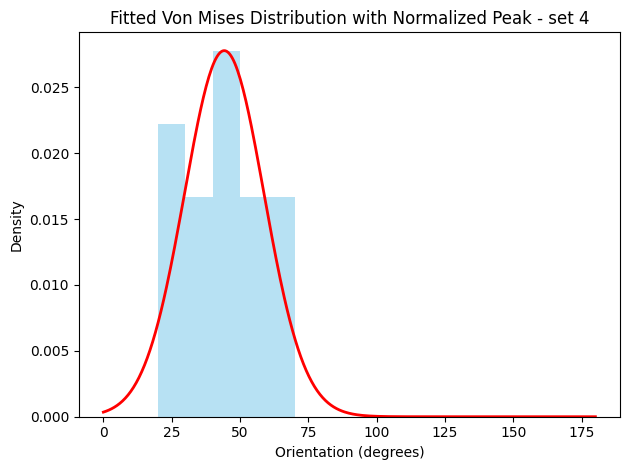

In [152]:
# Fracture set 4
current_set = FracSet4.copy()  # Use copy to avoid SettingWithCopyWarning
current_set['strike'] = (current_set['Azimuth [deg]'] - 90) % 360
current_set['correctedOrientation'] = current_set['strike'] % 180
(kappa,loc,_)=vonmises.fit(np.radians(current_set[['correctedOrientation']]), fscale=1)
print('set=4, Kappa=',kappa,'loc=',loc )

# Adjust the distribution curve plotting as before, with consideration for the full range
angles = np.linspace(0, 180, num=360)  # Use 180 
pdf_values  =vonmises.pdf(np.radians(angles), kappa=kappa, loc=loc)

# Calculate histogram
hist_vals, bin_edges = np.histogram(current_set[['correctedOrientation']], bins=18, range=(0, 180), density=True)


# Find the maximum height of the histogram bins
max_hist_height = max(hist_vals)
# Normalize the PDF to have the same peak as the histogram
pdf_values_normalized = pdf_values * (max_hist_height / max(pdf_values))

# Plot the histogram of the corrected orientations
plt.hist(current_set[['correctedOrientation']], bins=18, range=(0, 180), color='skyblue', alpha=0.6, density=True)
# Plot the normalized PDF of the fitted von Mises distribution
plt.plot(angles, pdf_values_normalized, 'r-', linewidth=2)

# Set plot labels and title
plt.xlabel('Orientation (degrees)')
plt.ylabel('Density')
plt.title('Fitted Von Mises Distribution with Normalized Peak - set 4')

# Show the plot
plt.tight_layout()
plt.show()

### Intensity

In [153]:
# True interval length
interval_TVD = TVD_data["TVD axis [m]"].iloc[-1] - TVD_data["TVD axis [m]"].iloc[0]
print (interval_TVD)

549.44


In [154]:
# Calculate average dip angle 
dip_set1 = np.mean (FracSet1['Dip [deg]'])
dip_set1Light = np.mean (FracSet1Light['Dip [deg]'])
dip_set2 = np.mean (FracSet2['Dip [deg]'])
dip_set3 = np.mean (FracSet3['Dip [deg]'])
dip_set4 = np.mean (FracSet4['Dip [deg]'])

print ('The mean dip angle of fracture set 1 is', dip_set1)
print ('The mean dip angle of fracture set 1 (light) is', dip_set1Light )
print ('The mean dip angle of fracture set 2 is', dip_set2)
print ('The mean dip angle of fracture set 3 is', dip_set3)
print ('The mean dip angle of fracture set 4 is', dip_set4)

The mean dip angle of fracture set 1 is 65.7959649122807
The mean dip angle of fracture set 1 (light) is 66.65329268292683
The mean dip angle of fracture set 2 is 58.58619047619048
The mean dip angle of fracture set 3 is 60.38928571428572
The mean dip angle of fracture set 4 is 49.79111111111111


In [193]:
# Calculate p10
p10_set1 = len(FracSet1['Fracture Set']) / (interval_TVD * np.sin (np.radians(90-dip_set1)))
p10_set1Light = len(FracSet1Light['Fracture Set']) / (interval_TVD * np.sin (np.radians(90-dip_set1Light)))
p10_set2 = len(FracSet2['Fracture Set']) / (interval_TVD * np.sin (np.radians(90-dip_set2)))
p10_set3 = len(FracSet3['Fracture Set']) / (interval_TVD * np.sin (np.radians(90-dip_set3)))
p10_set4 = len(FracSet4['Fracture Set']) / (interval_TVD * np.sin (np.radians(90-dip_set4)))

print ('The p10 of fracture set 1 is', p10_set1)
print ('The p10 of fracture set 1 (light) is', p10_set1Light)
print ('The p10 of fracture set 2 is', p10_set2)
print ('The p10 of fracture set 3 is', p10_set3)
print ('The p10 of fracture set 4 is', p10_set4)

The p10 of fracture set 1 is 1.0121484210755418
The p10 of fracture set 1 (light) is 0.7531924951702988
The p10 of fracture set 2 is 0.07333002472562247
The p10 of fracture set 3 is 0.051569033763144874
The p10 of fracture set 4 is 0.05074634139904132


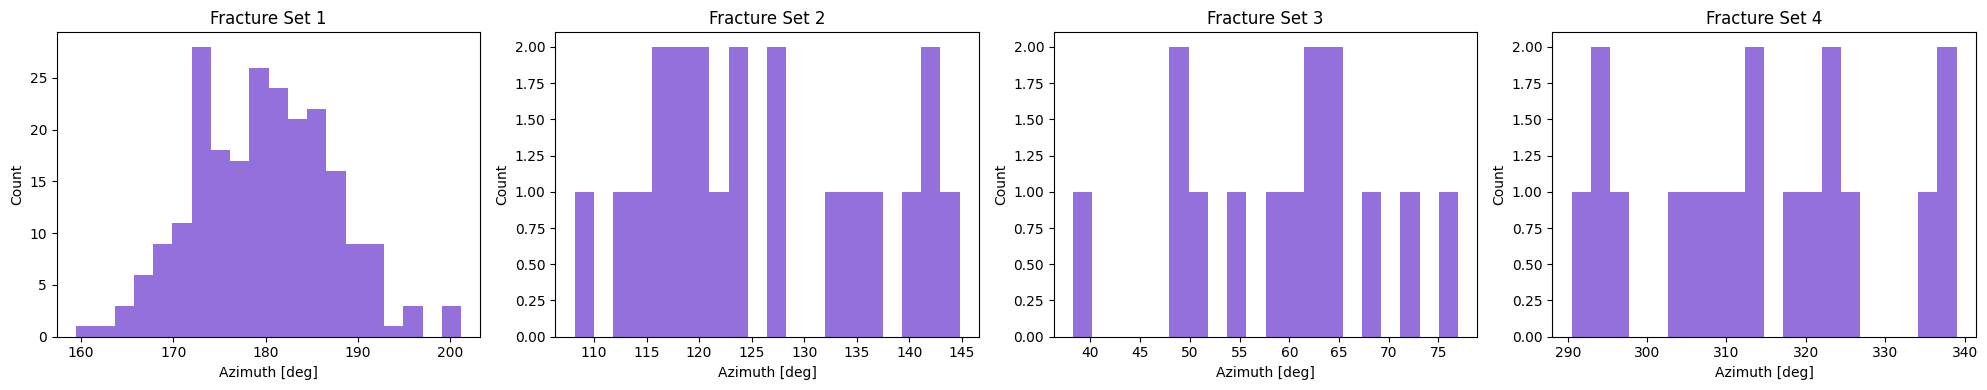

In [156]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i in range(4):
    subset = fracture_data[fracture_data["Fracture Set"] == i]
    axes[i].hist(subset["Azimuth [deg]"], bins=20, color='mediumpurple')
    axes[i].set_title(f"Fracture Set {i+1}")
    axes[i].set_xlabel("Azimuth [deg]")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

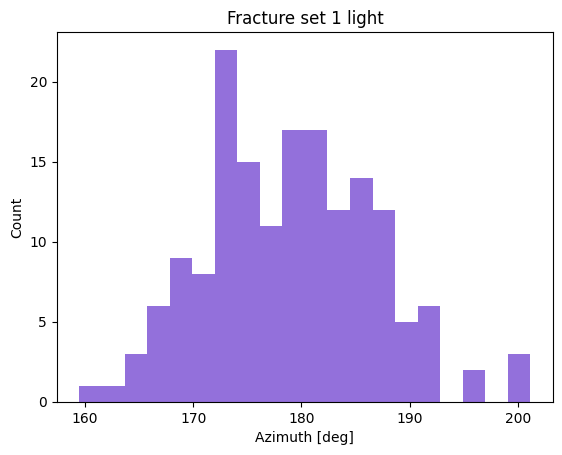

In [157]:
plt.hist(FracSet1Light["Azimuth [deg]"], bins=20, color='mediumpurple')
plt.title('Fracture set 1 light')
plt.xlabel("Azimuth [deg]")
plt.ylabel("Count")

In [158]:
# Calculate p21
p21_set1 = p10_set1
p21_set1Light = p10_set1Light
p21_set2 = p10_set2 * (2 * (np.pi/4))
p21_set3 = p10_set3 * (2 * (np.pi/4))
p21_set4 = p10_set4 * (2 * (np.pi/4))
print ('The p21 of fracture set 1 is', p21_set1)
print ('The p21 of fracture set 1 (light) is', p21_set1Light)
print ('The p21 of fracture set 2 is', p21_set2)
print ('The p21 of fracture set 3 is', p21_set3)
print ('The p21 of fracture set 4 is', p21_set4)

The p21 of fracture set 1 is 0.45496321747269847
The p21 of fracture set 1 (light) is 0.32510407261943786
The p21 of fracture set 2 is 0.0703482724314801
The p21 of fracture set 3 is 0.04603696987124887
The p21 of fracture set 4 is 0.06738320430392816


### Spatial distribution 

In [159]:
# Calculating the spacing between neighbouring fractures for each set 

# Set 1
spacing_set1 = []

for i in range(len(FracSet1['TVD']) - 1):
    # Calculate the average dip and vertical distance between the two angles
    dip_avg = (FracSet1['Dip [deg]'].iloc[i] + FracSet1['Dip [deg]'].iloc[i+1]) / 2
    vertical = FracSet1['TVD'].iloc[i+1] - FracSet1['TVD'].iloc[i]
    # Calculate the distance
    dist = vertical * np.sin(np.radians(90-dip_avg))
    # Append to distance list 
    spacing_set1.append(dist)

# Set 1 (light)
spacing_set1Light = []

for i in range(len(FracSet1Light['TVD']) - 1):
    # Calculate the average dip and vertical distance between the two angles
    dip_avg = (FracSet1Light['Dip [deg]'].iloc[i] + FracSet1Light['Dip [deg]'].iloc[i+1]) / 2
    vertical = FracSet1Light['TVD'].iloc[i+1] - FracSet1Light['TVD'].iloc[i]
    # Calculate the distance
    dist = vertical * np.sin(np.radians(90-dip_avg))
    # Append to distance list 
    spacing_set1Light.append(dist)

# Set 2
spacing_set2 = []

for i in range(len(FracSet2['TVD']) - 1):
    # Calculate the average dip and vertical distance between the two angles
    dip_avg = (FracSet2['Dip [deg]'].iloc[i] + FracSet2['Dip [deg]'].iloc[i+1]) / 2
    vertical = FracSet2['TVD'].iloc[i+1] - FracSet2['TVD'].iloc[i]
    # Calculate the distance
    dist = vertical * np.sin(np.radians(90-dip_avg))
    # Append to distance list 
    spacing_set2.append(dist)

# Set 3
spacing_set3 = []

for i in range(len(FracSet3['TVD']) - 1):
    # Calculate the average dip and vertical distance between the two angles
    dip_avg = (FracSet3['Dip [deg]'].iloc[i] + FracSet3['Dip [deg]'].iloc[i+1]) / 2
    vertical = FracSet3['TVD'].iloc[i+1] - FracSet3['TVD'].iloc[i]
    # Calculate the distance
    dist = vertical * np.sin(np.radians(90-dip_avg))
    # Append to distance list 
    spacing_set3.append(dist)

# Set 4
spacing_set4 = []

for i in range(len(FracSet4['TVD']) - 1):
    # Calculate the average dip and vertical distance between the two angles
    dip_avg = (FracSet4['Dip [deg]'].iloc[i] + FracSet4['Dip [deg]'].iloc[i+1]) / 2
    vertical = FracSet4['TVD'].iloc[i+1] - FracSet4['TVD'].iloc[i]
    # Calculate the distance
    dist = vertical * np.sin(np.radians(90-dip_avg))
    # Append to distance list 
    spacing_set4.append(dist)

In [160]:
def plot_uniform_powerlaw_fit(spacing_set1, set_label='Set 1', num_bins=200):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    spacing = np.asarray(spacing_set1)

    hist_vals, bin_edges = np.histogram(spacing, bins=num_bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    distributions = {
        'uniform': {
            'func': lambda x: np.ones_like(x) * (1.0 / (max(spacing) - min(spacing))),
            'params': lambda: {'dmin': min(spacing), 'dmax': max(spacing)}
        },
        'power law': {
            'func': lambda x: stats.powerlaw.pdf(x, *stats.powerlaw.fit(spacing)),
            'params': lambda: {
                'alpha': stats.powerlaw.fit(spacing)[0],
                'dmin': min(spacing),
                'dmax': max(spacing)
            }
        }
    }

    fit_results = []

    for ax, (name, dist) in zip(axs, distributions.items()):
        try:
            y_fit = dist['func'](bin_centers)
            params = dist['params']()
        except Exception as e:
            print(f"Could not fit {name} distribution due to: {e}")
            continue

        fit_results.append({'distribution': name, **params})

        # Plot histogram + fitted curve
        ax.hist(spacing, bins=num_bins, color='steelblue', alpha=0.6, density=True)
        ax.plot(bin_centers, y_fit, 'k-', linewidth=2)
        ax.set_title(f'{set_label} - {name}')
        ax.set_xlabel('Spacing')
        ax.axhline(y=0.001, color='gray', linestyle='--', linewidth=1)

    axs[0].set_ylabel('Density')

    fit_df = pd.DataFrame(fit_results)
    print(fit_df)

    plt.tight_layout()
    plt.show()

    return fit_df

  distribution      dmin      dmax     alpha
0      uniform  0.009594  9.134369       NaN
1    power law  0.009594  9.134369  0.302098


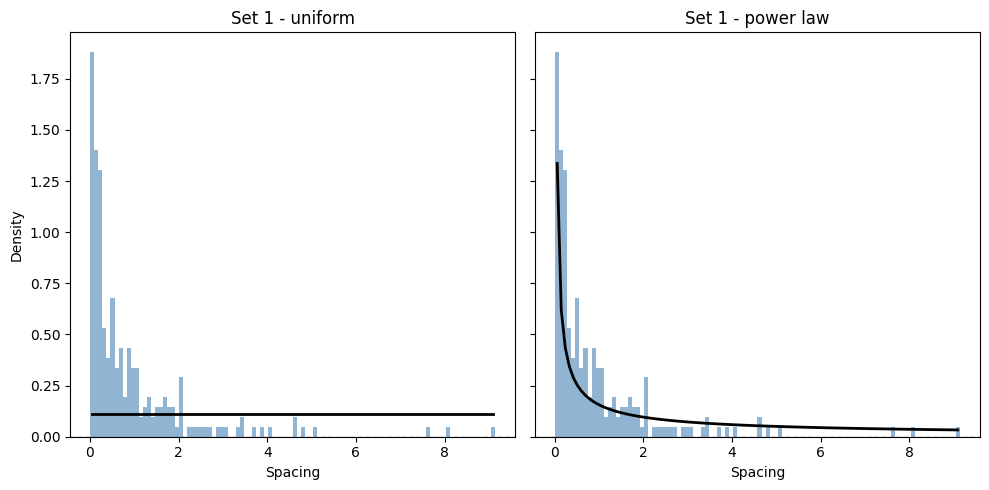

,distribution,dmin,dmax,alpha
0,uniform,0.009594,9.134369,NaN
1,power law,0.009594,9.134369,0.302098


In [161]:
plot_uniform_powerlaw_fit(spacing_set1, set_label='Set 1', num_bins=100)

  distribution      dmin       dmax     alpha
0      uniform  0.009594  12.970349       NaN
1    power law  0.009594  12.970349  0.285796


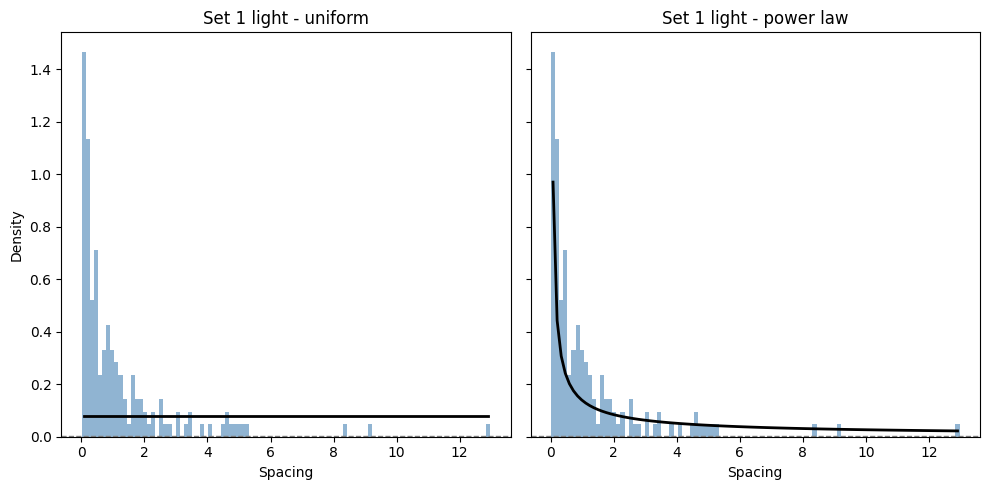

,distribution,dmin,dmax,alpha
0,uniform,0.009594,12.970349,NaN
1,power law,0.009594,12.970349,0.285796


In [162]:
plot_uniform_powerlaw_fit(spacing_set1Light, set_label='Set 1 light', num_bins=100)

  distribution      dmin       dmax     alpha
0      uniform  0.052135  67.542574       NaN
1    power law  0.052135  67.542574  0.215132


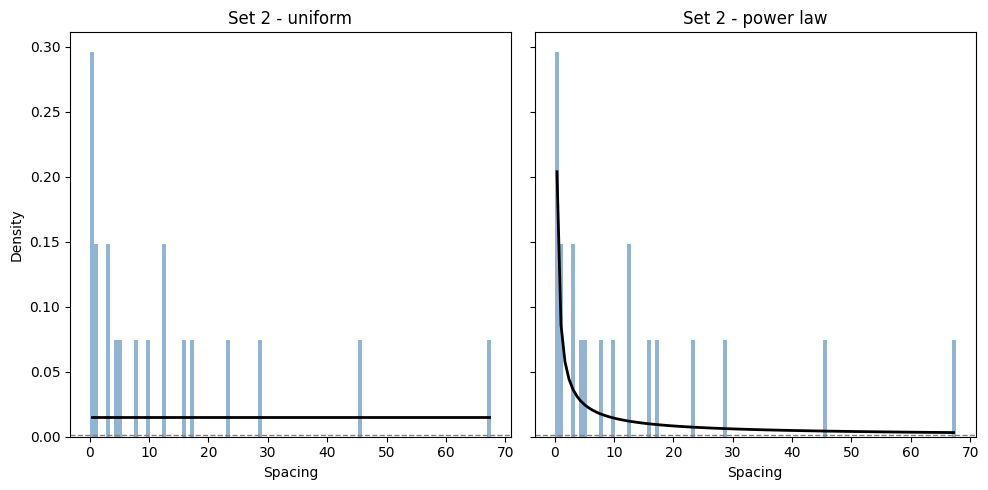

,distribution,dmin,dmax,alpha
0,uniform,0.052135,67.542574,NaN
1,power law,0.052135,67.542574,0.215132


In [163]:
plot_uniform_powerlaw_fit(spacing_set2, set_label='Set 2', num_bins=100)

  distribution     dmin       dmax     alpha
0      uniform  0.12438  95.920211       NaN
1    power law  0.12438  95.920211  0.184365


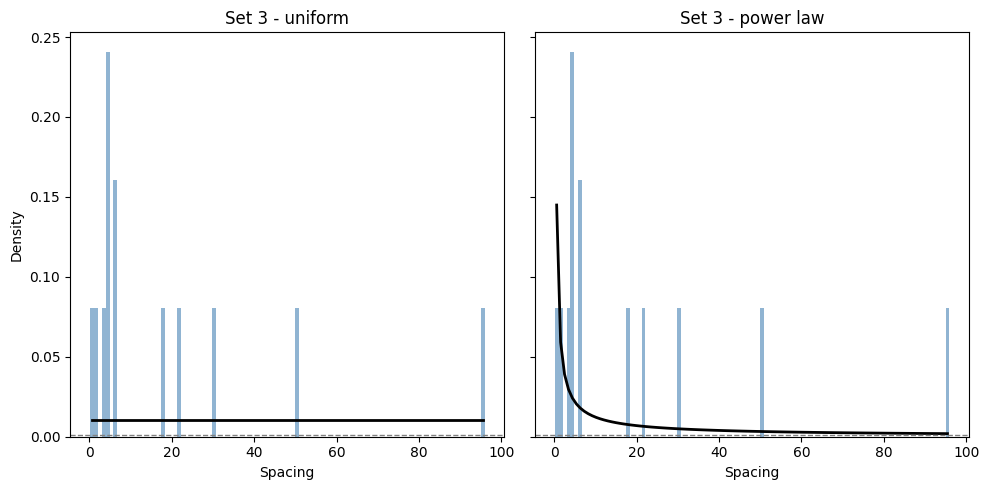

,distribution,dmin,dmax,alpha
0,uniform,0.12438,95.920211,NaN
1,power law,0.12438,95.920211,0.184365


In [164]:
plot_uniform_powerlaw_fit(spacing_set3, set_label='Set 3', num_bins=100)

  distribution      dmin       dmax     alpha
0      uniform  0.749208  40.908442       NaN
1    power law  0.749208  40.908442  0.271033


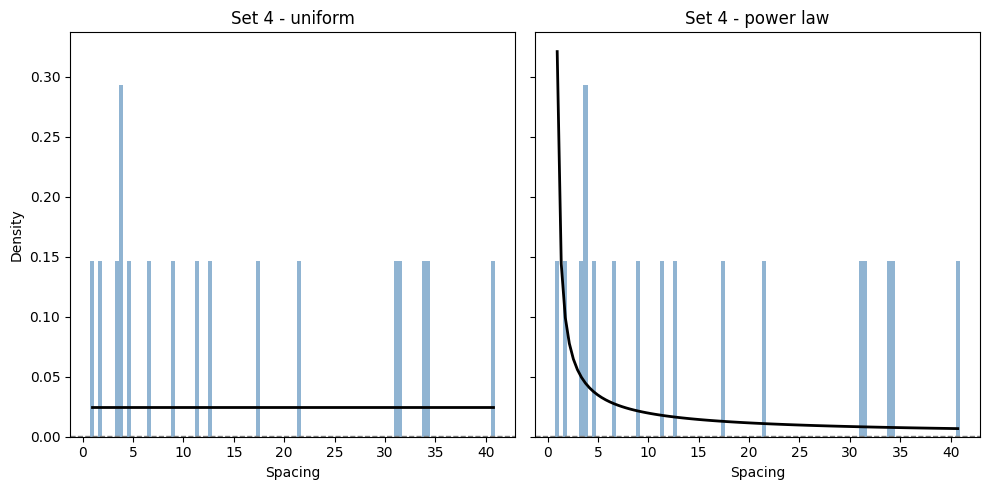

,distribution,dmin,dmax,alpha
0,uniform,0.749208,40.908442,NaN
1,power law,0.749208,40.908442,0.271033


In [165]:
plot_uniform_powerlaw_fit(spacing_set4, set_label='Set 4', num_bins=100)

75.56256346111964


(array([2.233e+03, 1.921e+03, 1.672e+03, 1.555e+03, 1.589e+03, 1.330e+03,
        1.326e+03, 1.335e+03, 1.415e+03, 1.313e+03, 1.120e+03, 1.066e+03,
        1.007e+03, 1.013e+03, 8.340e+02, 7.060e+02, 5.690e+02, 5.340e+02,
        5.080e+02, 4.400e+02, 4.250e+02, 3.630e+02, 3.230e+02, 2.800e+02,
        2.340e+02, 1.690e+02, 1.610e+02, 1.290e+02, 9.300e+01, 7.300e+01,
        5.100e+01, 2.400e+01, 2.200e+01, 2.500e+01, 4.000e+00, 6.000e+00,
        5.000e+00, 3.000e+00, 0.000e+00, 2.000e+00]),
 array([9.59358815e-03, 8.20103488e+00, 1.63924762e+01, 2.45839175e+01,
        3.27753588e+01, 4.09668001e+01, 4.91582414e+01, 5.73496827e+01,
        6.55411240e+01, 7.37325653e+01, 8.19240066e+01, 9.01154479e+01,
        9.83068891e+01, 1.06498330e+02, 1.14689772e+02, 1.22881213e+02,
        1.31072654e+02, 1.39264096e+02, 1.47455537e+02, 1.55646978e+02,
        1.63838420e+02, 1.72029861e+02, 1.80221302e+02, 1.88412743e+02,
        1.96604185e+02, 2.04795626e+02, 2.12987067e+02, 2.21178509e+02

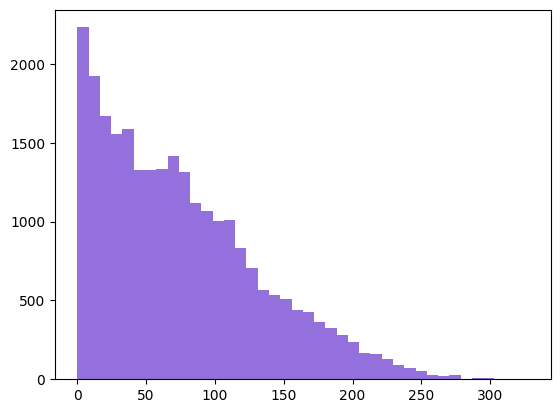

In [166]:
# Calculating the spacing between all fractures 

# Create an empty list to store the distances
spacing_set1_all = []

n = len(FracSet1['TVD'])

for i in range(n):
    for j in range(i+1, n):
        # Calculate the average dip and vertical distance between the two angles
        dip_avg = (FracSet1['Dip [deg]'].iloc[i] + FracSet1['Dip [deg]'].iloc[j]) / 2
        vertical = FracSet1['TVD'].iloc[j] - FracSet1['TVD'].iloc[i]
        # Calculate the distance
        dist = vertical * np.sin(np.radians(90-dip_avg))
        # Append to distance list 
        spacing_set1_all.append(dist)

print (np.mean (spacing_set1_all))
plt.hist (spacing_set1_all, color='mediumpurple', bins=40)

### Aperture fitting 

In [167]:
# Function to fit a power law to the aperture statistics 

def _pdf_norm(alpha, min_val, max_val):
    """Normalizing constant C for f(x) = C * x^(-alpha) on [min_val, max_val]."""
    if abs(alpha - 1) < 1e-8:
        return 1.0 / np.log(max_val / min_val)
    else:
        a = 1 - alpha
        return a / (max_val**a - min_val**a)

def _powerlaw_moment(alpha, min_val, max_val, order=1):
    """E[X^order] for the truncated power law, via numerical integration."""
    C = _pdf_norm(alpha, min_val, max_val)
    val, _ = integrate.quad(lambda x: (x**order) * C * x**(-alpha), min_val, max_val)
    return val

def _powerlaw_mean_std(alpha, min_val, max_val):
    m1 = _powerlaw_moment(alpha, min_val, max_val, 1)
    m2 = _powerlaw_moment(alpha, min_val, max_val, 2)
    std = np.sqrt(max(m2 - m1**2, 0))
    return m1, std

def _inverse_cdf(u, alpha, min_val, max_val):
    """Analytic inverse CDF for sampling."""
    if abs(alpha - 1) < 1e-8:
        return min_val * (max_val / min_val) ** u
    else:
        a = 1 - alpha
        return (min_val**a + u * (max_val**a - min_val**a)) ** (1 / a)

def generate_samples_powerlaw(n_samples, mean, std, min_val, max_val,
                               match='mean', seed=None):
    """
    Generate synthetic samples from a truncated power law f(x) = C * x^(-alpha)
    on [min_val, max_val], fit to match either the target mean or target std
    (only one is achievable exactly, since alpha is the only free parameter).

    Parameters
    ----------
    n_samples : int
    mean, std : float      Target mean and std (only one will be matched exactly)
    min_val, max_val : float
    match : 'mean' or 'std'  Which moment to fit alpha to
    seed : int, optional

    Returns
    -------
    samples : np.ndarray
    alpha : float           Fitted scaling exponent
    C : float                Fitted scaling coefficient
    """
    rng = np.random.default_rng(seed)

    if match == 'mean':
        target = mean
        objective = lambda a: _powerlaw_mean_std(a, min_val, max_val)[0] - target
    elif match == 'std':
        target = std
        objective = lambda a: _powerlaw_mean_std(a, min_val, max_val)[1] - target
    else:
        raise ValueError("match must be 'mean' or 'std'")

    alpha = optimize.brentq(objective, -10, 15, xtol=1e-8)
    C = _pdf_norm(alpha, min_val, max_val)

    u = rng.uniform(0, 1, size=n_samples)
    samples = _inverse_cdf(u, alpha, min_val, max_val)

    return samples, alpha, C

In [168]:
# Create aperture random samples 
n = 500
mean = 5.07
std = 2.91
min_val = 1.81
max_val = 11.46

aperture_samples, alpha, C = generate_samples_powerlaw(n, mean, std, min_val, max_val,
                                               match='mean', seed=42)

print(f"Fitted scaling exponent (alpha): {alpha:.3f}")
print(f"Fitted scaling coefficient (C):  {C:.5f}")
print(f"Target :  mean={mean:.2f}, std={std:.2f}")
print(f"Sample :  mean={aperture_samples.mean():.2f}, std={aperture_samples.std():.2f}, "
      f"min={aperture_samples.min():.2f}, max={aperture_samples.max():.2f}")

Fitted scaling exponent (alpha): 1.114
Fitted scaling coefficient (C):  0.64266
Target :  mean=5.07, std=2.91
Sample :  mean=5.01, std=2.61, min=1.83, max=11.44


mean 5.013293341651637
std 2.6056246877898293
min 1.8264432092492229
max 11.43895249892745


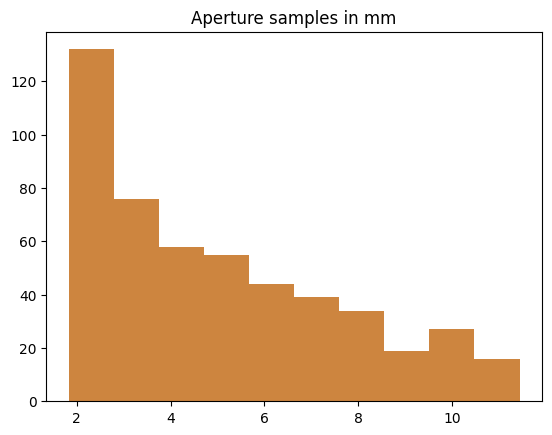

In [169]:
plt.hist (aperture_samples, color='peru')
plt.title ('Aperture samples in mm')
print ('mean', np.mean(aperture_samples))
print ('std', np.std(aperture_samples))
print ('min', np.min (aperture_samples))
print ('max', np.max (aperture_samples))

### Length

In [170]:
# Convert parture data form mm to m
apertures = aperture_samples / 1000

In [171]:
# Length array min
length_min = (apertures/0.00096)**(1/0.38)

In [172]:
# Length array max
length_max = (apertures/0.00069)**(1/0.41)

In [173]:
# Distribution fitting function 

def plot_powerlaw_expon_fit(data, set_label, num_bins=200):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    data = np.asarray(data)
    hist_vals, bin_edges = np.histogram(data, bins=num_bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    distributions = {
        'exponential': {
            'func': lambda x: stats.expon.pdf(x, *stats.expon.fit(data)),
            'params': lambda: {
                'lambda': 1 / stats.expon.fit(data)[1],
                'min': stats.expon.fit(data)[0],
                'max': max(data)
            },
        },
        'power law': {
            'func': lambda x: stats.powerlaw.pdf(x, *stats.powerlaw.fit(data)),
            'params': lambda: {
                'alpha': stats.powerlaw.fit(data)[0],
                'dmin': min(data),
                'dmax': max(data)
            }
        }
    }
    fit_results = []
    for ax, (name, dist) in zip(axs, distributions.items()):
        try:
            y_fit = dist['func'](bin_centers)
            params = dist['params']()
        except Exception as e:
            print(f"Could not fit {name} distribution due to: {e}")
            continue
        fit_results.append({'distribution': name, **params})
        # Plot histogram + fitted curve
        ax.hist(data, bins=num_bins, color='steelblue', alpha=0.6, density=True)
        ax.plot(bin_centers, y_fit, 'k-', linewidth=2)
        ax.set_title(f'{set_label} - {name}')
        ax.set_xlabel('Length')
        ax.axhline(y=0.001, color='gray', linestyle='--', linewidth=1)
    axs[0].set_ylabel('Density')
    fit_df = pd.DataFrame(fit_results)
    print(fit_df)
    plt.tight_layout()
    plt.show()
    return fit_df

  distribution    lambda       min         max     alpha      dmin        dmax
0  exponential  0.008347  5.433654  679.018553       NaN       NaN         NaN
1    power law       NaN       NaN         NaN  0.338512  5.433654  679.018553


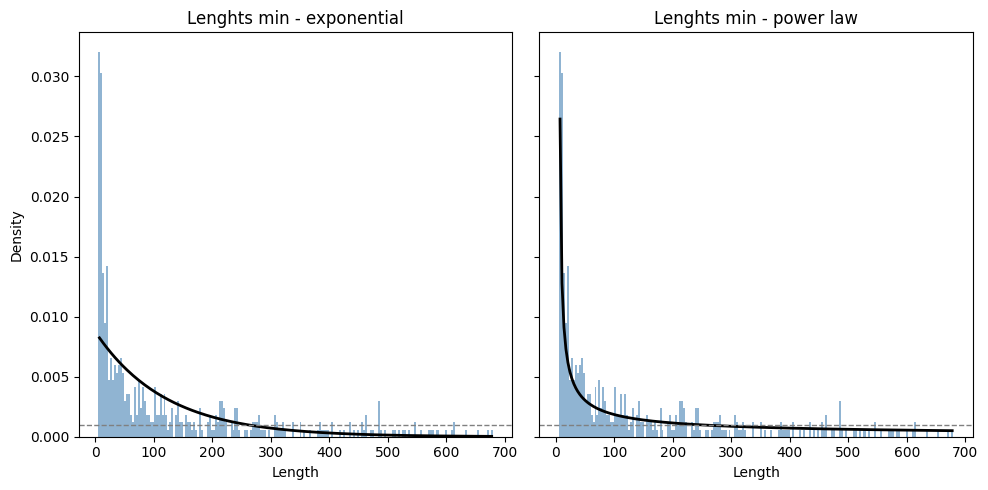

,distribution,lambda,min,max,alpha,dmin,dmax
0,exponential,0.008347,5.433654,679.018553,NaN,NaN,NaN
1,power law,NaN,NaN,NaN,0.338512,5.433654,679.018553


In [174]:
# Lenght fitting min
plot_powerlaw_expon_fit(length_min, set_label='Lenghts min', num_bins=200)

  distribution    lambda        min         max    alpha       dmin  \
0  exponential  0.005633  10.742734  942.933124      NaN        NaN   
1    power law       NaN        NaN         NaN  0.35803  10.742734   

         dmax  
0         NaN  
1  942.933124  


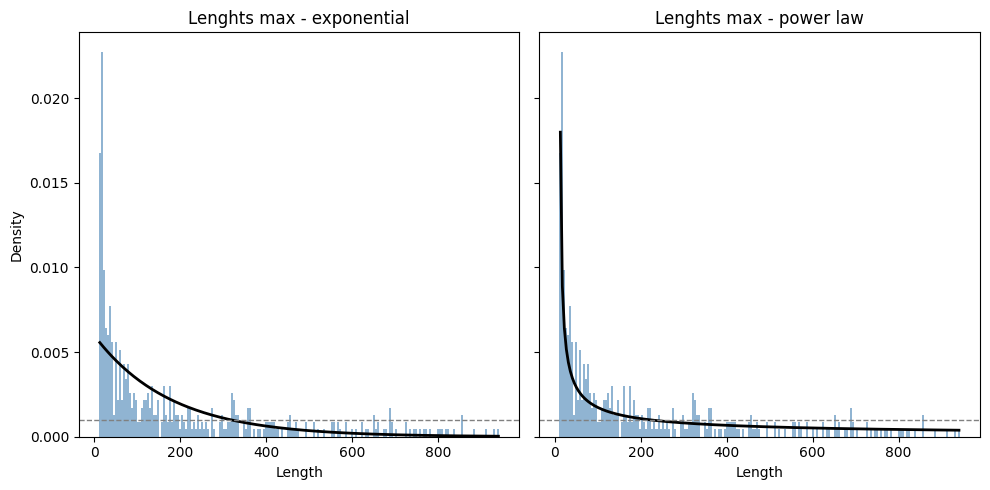

,distribution,lambda,min,max,alpha,dmin,dmax
0,exponential,0.005633,10.742734,942.933124,NaN,NaN,NaN
1,power law,NaN,NaN,NaN,0.35803,10.742734,942.933124


In [175]:
# Length fitting max
plot_powerlaw_expon_fit(length_max, set_label='Lenghts max', num_bins=200)

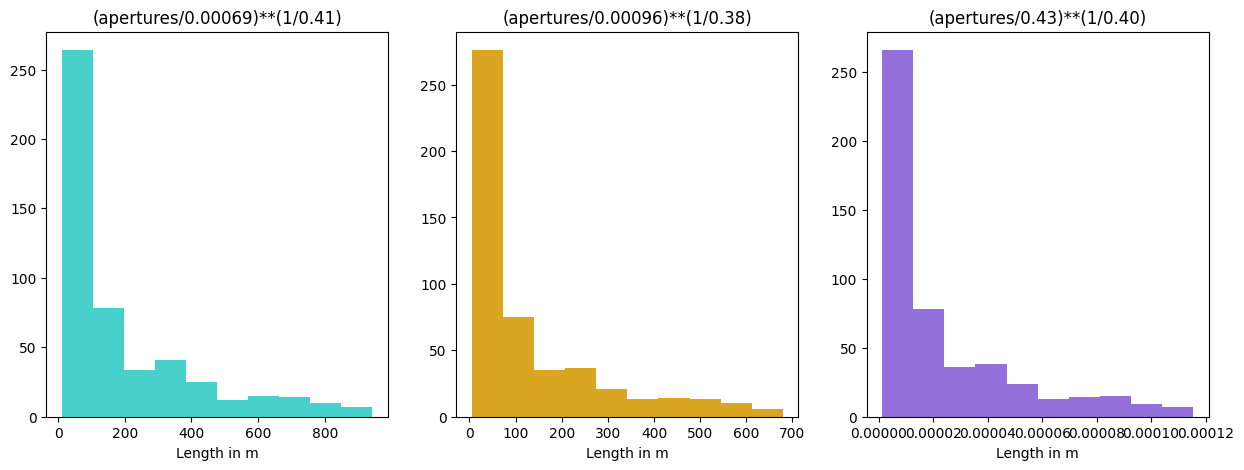

In [186]:
# All three equations 
length_eq1 = (apertures/0.00069)**(1/0.41)
length_eq2 = (apertures/0.00096)**(1/0.38)
length_eq3 = (apertures/0.43)**(1/0.40)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.hist (length_eq1, color='mediumturquoise')
ax1.set_title ('(apertures/0.00069)**(1/0.41)')
ax1.set_xlabel ('Length in m')

ax2.hist (length_eq2, color='goldenrod')
ax2.set_title ('(apertures/0.00096)**(1/0.38)')
ax2.set_xlabel ('Length in m')

ax3.hist (length_eq3, color='mediumpurple')
ax3.set_title ('(apertures/0.43)**(1/0.40)')
ax3.set_xlabel ('Length in m')

plt.show()